In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    CAPTIONS_PATH,
    CVA_EM_4_PATH,
    ERA_EM_PATHS,
    FIGURES_PATH,
    LATENT_DIMS,
    N_BURNIN,
    N_FFT,
    N_MARKOV,
    RANDOM_SEED,
)
from era_utils import estimate_markov_ols
from freq_map import (
    NOTEBOOK_GITHUB_URL,
    compute_analytic_response,
    compute_empirical_response,
    make_freq_map_figure,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
FREQ_MAP_SEED       = 3     # Brain seed for empirical frequency response
FREQ_MAP_DRIVE_SEED = 4     # RNG seed for i.i.d. input sequence
FREQ_MAP_N_SAMPLES  = 5000  # recording length (steps, after burn-in)

In [3]:
# ── derived: Brain input dimension and all estimator matrices ─────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
del _b

ERA_EM_ESTIMATES: list[SystemEstimate] = [SystemEstimate.load(p) for p in ERA_EM_PATHS]
CVA_EM_4: SystemEstimate = SystemEstimate.load(CVA_EM_4_PATH)

for n_x, est in zip(LATENT_DIMS, ERA_EM_ESTIMATES):
    print(f"ERA+EM n_x={n_x}  A: {est.A.shape},  label: {est.label}")
print(f"CVA+EM n_x=4   A: {CVA_EM_4.A.shape},  label: {CVA_EM_4.label}")
print(f"n_u = {P_DIM}")

ERA+EM n_x=2  A: (2, 2),  label: ERA+EM $n_x=2$
ERA+EM n_x=4  A: (4, 4),  label: ERA+EM $n_x=4$
ERA+EM n_x=6  A: (6, 6),  label: ERA+EM $n_x=6$
CVA+EM n_x=4   A: (4, 4),  label: CVA+EM $n_x=4$
n_u = 2


In [4]:
# ── simulation: Markov parameters and frequency responses ────────────────────
markov = estimate_markov_ols(
    FREQ_MAP_SEED,
    FREQ_MAP_DRIVE_SEED,
    P_DIM,
    N_MARKOV,
    FREQ_MAP_N_SAMPLES,
    N_BURNIN,
)

freqs, H_emp = compute_empirical_response(markov, n_fft=N_FFT)

# ERA+EM at n_x = 2, 4, 6 (latent dim sweep), then CVA+EM at n_x = 4 (estimator comparison)
model_responses: list[tuple[str, np.ndarray]] = [
    (est.label, compute_analytic_response(est.A, est.B, est.C, freqs))
    for est in ERA_EM_ESTIMATES
] + [
    (CVA_EM_4.label, compute_analytic_response(CVA_EM_4.A, CVA_EM_4.B, CVA_EM_4.C, freqs))
]

print(f"Frequency grid: {len(freqs)} points in [0, π]")
print(f"H_emp: {H_emp.shape}")
for label, H in model_responses:
    print(f"  {label:25s}  H: {H.shape}")

Frequency grid: 257 points in [0, π]
H_emp: (257, 16, 2)
  ERA+EM $n_x=2$             H: (257, 16, 2)
  ERA+EM $n_x=4$             H: (257, 16, 2)
  ERA+EM $n_x=6$             H: (257, 16, 2)
  CVA+EM $n_x=4$             H: (257, 16, 2)


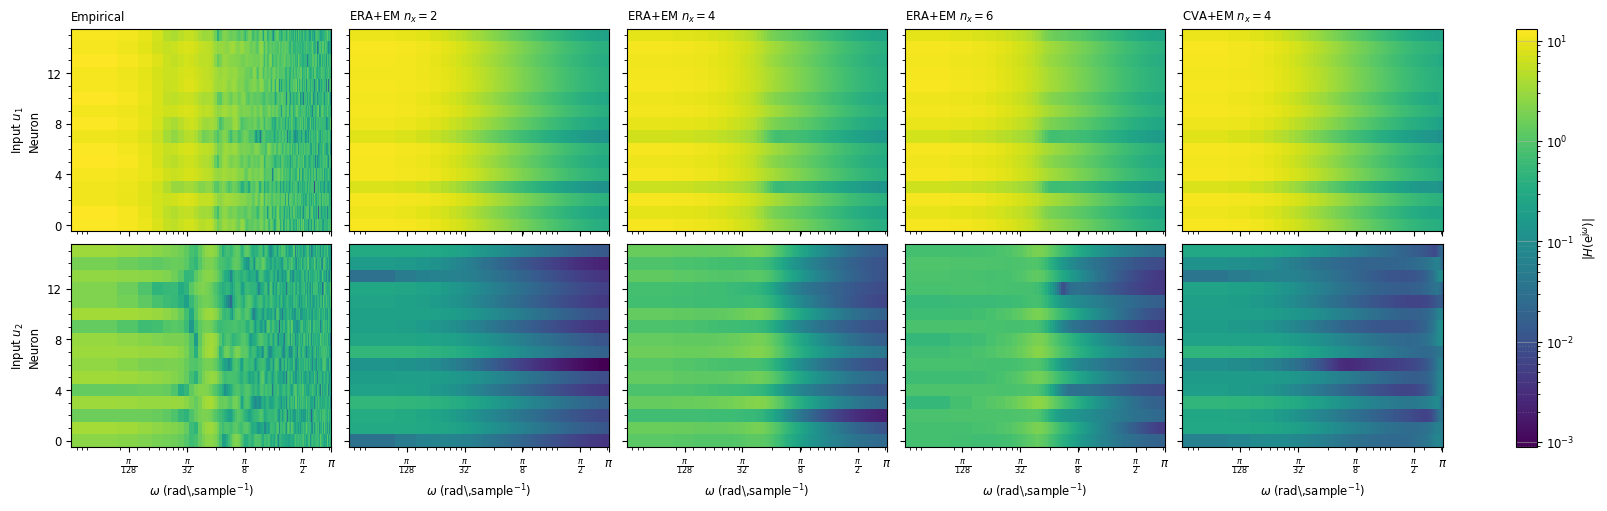

In [5]:
# ── figure: display ──────────────────────────────────────────────────────────
configure_screen()
fig = make_freq_map_figure(freqs, H_emp, model_responses, figsize=(16, 5))
apply_figure_style(fig)
plt.show()

In [6]:
# ── pgf export ───────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.22  # fraction of A4 content height (5 columns, 2 rows)

configure_pgf()
fig = make_freq_map_figure(
    freqs, H_emp, model_responses,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "freq_map.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/freq_map.pgf


In [7]:
# ── caption ─────────────────────────────────────────────────────────────────────────────
q = ERA_EM_ESTIMATES[0].C.shape[0]

caption = (
    r"Per-neuron frequency selectivity for inputs $u_1$ (top row) and $u_2$"
    r" (bottom row). Each panel shows $|H(\mathrm{e}^{\mathrm{j}\omega})|$"
    r" for all $n_y = "
    + str(q)
    + r"$ neurons (vertical axis) across $\omega \in [0, \pi]$"
    r" rad\,sample$^{-1}$ (horizontal axis), on a shared logarithmic colour scale."
    r" Leftmost column: empirical response (honest OLS estimate from a single "
    + str(FREQ_MAP_N_SAMPLES)
    + r"-step recording, DFT zero-padded to "
    + str(N_FFT)
    + r" points). Columns 2--4: analytic ERA+EM transfer function"
    r" $H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$"
    r" for $n_x \in \{2, 4, 6\}$ respectively, showing the latent dimension sweep."
    r" Rightmost column: CVA+EM at $n_x = 4$, for estimator comparison at the chosen order."
)
save_caption(CAPTIONS_PATH / "freq_map.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/freq_map.tex
Per-neuron frequency selectivity for inputs $u_1$ (top row) and $u_2$ (bottom row). Each panel shows $|H(\mathrm{e}^{\mathrm{j}\omega})|$ for all $n_y = 16$ neurons (vertical axis) across $\omega \in [0, \pi]$ rad\,sample$^{-1}$ (horizontal axis), on a shared logarithmic colour scale. Leftmost column: empirical response (honest OLS estimate from a single 5000-step recording, DFT zero-padded to 512 points). Columns 2--4: analytic ERA+EM transfer function $H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$ for $n_x \in \{2, 4, 6\}$ respectively, showing the latent dimension sweep. Rightmost column: CVA+EM at $n_x = 4$, for estimator comparison at the chosen order.
